# Tulya Training Dynamics — Grokking Experiment

This notebook is self-contained and synced from `kaggle_grokking_experiment.py`.

**Recommended workflow**
1. Run the environment check.
2. Run the core implementation cell once.
3. Run the 2,000-step sanity experiment.
4. Inspect the plots and sanity checks.
5. Only then enable the 40,000-step full run.

The experiment separates online-available `feature_*` metrics from retrospective `label_*` quantities to avoid accidental leakage when we later build an early-warning predictor.

In [1]:
import os, json, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
else:
    print("WARNING: GPU is not enabled. In Kaggle, open Settings -> Accelerator and select a GPU.")

os.makedirs("/kaggle/working/tulya_runs", exist_ok=True)

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU count: 2


## Core experiment implementation

This cell contains the same implementation as the repository's Python module. It is intentionally collapsed/large so the notebook can run by itself after being imported from GitHub.

In [2]:
#!/usr/bin/env python3
"""Kaggle-friendly grokking experiment with dense training-dynamics logging.

The file is intentionally self-contained. It separates online-available metrics
(`feature_*`) from held-out retrospective labels (`label_*`) so downstream
forecasting experiments cannot accidentally leak the future event.
"""
from __future__ import annotations

import argparse
import csv
import json
import math
import random
import time
from collections import deque
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Deque, Dict, Iterable, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


@dataclass
class ExperimentConfig:
    output_dir: str = "tulya_runs/grokking_seed_0"
    seed: int = 0
    modulus: int = 113
    operation: str = "add"  # add | subtract
    train_fraction: float = 0.30

    d_model: int = 128
    n_heads: int = 4
    d_mlp: int = 512
    n_layers: int = 1
    dropout: float = 0.0

    optimizer: str = "adamw"
    lr: float = 1e-3
    weight_decay: float = 1.0
    adam_beta1: float = 0.9
    adam_beta2: float = 0.98
    warmup_steps: int = 10
    batch_size: int = 0  # 0 = full batch (canonical grokking setup)
    max_steps: int = 40_000

    eval_every: int = 100
    diagnostics_every: int = 200
    update_probe_every: int = 10
    update_projection_dim: int = 256
    update_window: int = 64
    probe_examples: int = 1024
    eval_batch_size: int = 4096

    grok_threshold: float = 0.90
    grok_patience: int = 3
    memorization_train_threshold: float = 0.99
    memorization_test_ceiling: float = 0.50

    checkpoint_every: int = 1000
    keep_spectrum_values: int = 16
    device: str = "auto"
    deterministic: bool = False


def set_seed(seed: int, deterministic: bool = False) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass


def resolve_device(name: str) -> torch.device:
    if name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(name)


def make_modular_dataset(
    modulus: int,
    train_fraction: float,
    seed: int,
    operation: str,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    if not (0.0 < train_fraction < 1.0):
        raise ValueError("train_fraction must be strictly between 0 and 1")
    if modulus < 3:
        raise ValueError("modulus must be >= 3")

    pairs = [(a, b) for a in range(modulus) for b in range(modulus)]
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(pairs))
    split = int(len(pairs) * train_fraction)
    train_ids, test_ids = order[:split], order[split:]

    eq_token = modulus

    def build(ids: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
        xs: List[List[int]] = []
        ys: List[int] = []
        for idx in ids.tolist():
            a, b = pairs[idx]
            if operation == "add":
                y = (a + b) % modulus
            elif operation == "subtract":
                y = (a - b) % modulus
            else:
                raise ValueError(f"unsupported operation: {operation}")
            xs.append([a, b, eq_token])
            ys.append(y)
        return torch.tensor(xs, dtype=torch.long), torch.tensor(ys, dtype=torch.long)

    train_x, train_y = build(train_ids)
    test_x, test_y = build(test_ids)
    return train_x, train_y, test_x, test_y


class DiagnosticBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_mlp: int, dropout: float) -> None:
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model,
            n_heads,
            dropout=dropout,
            bias=False,
            batch_first=True,
        )
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_mlp, bias=False),
            nn.ReLU(),
            nn.Linear(d_mlp, d_model, bias=False),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(
        self, x: torch.Tensor, need_attention: bool = False
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        seq_len = x.shape[1]
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, dtype=torch.bool, device=x.device),
            diagonal=1,
        )
        attn_out, attn_weights = self.attn(
            x,
            x,
            x,
            attn_mask=causal_mask,
            need_weights=need_attention,
            average_attn_weights=False,
        )
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.mlp(x))
        return x, attn_weights if need_attention else None


class ModularTransformer(nn.Module):
    def __init__(self, cfg: ExperimentConfig) -> None:
        super().__init__()
        self.modulus = cfg.modulus
        self.seq_len = 3
        self.token_embedding = nn.Embedding(cfg.modulus + 1, cfg.d_model)
        self.position_embedding = nn.Parameter(torch.zeros(1, self.seq_len, cfg.d_model))
        self.blocks = nn.ModuleList(
            [
                DiagnosticBlock(cfg.d_model, cfg.n_heads, cfg.d_mlp, cfg.dropout)
                for _ in range(cfg.n_layers)
            ]
        )
        self.unembed = nn.Linear(cfg.d_model, cfg.modulus, bias=False)
        nn.init.normal_(self.position_embedding, std=0.02)

    def forward(
        self, tokens: torch.Tensor, diagnostics: bool = False
    ) -> Tuple[torch.Tensor, Optional[Dict[str, Any]]]:
        x = self.token_embedding(tokens) + self.position_embedding
        diag: Optional[Dict[str, Any]] = None
        if diagnostics:
            diag = {"input_representation": x.detach(), "block_outputs": [], "attention": []}

        for block in self.blocks:
            x, attn = block(x, need_attention=diagnostics)
            if diagnostics and diag is not None:
                diag["block_outputs"].append(x.detach())
                diag["attention"].append(attn.detach() if attn is not None else None)

        final_repr = x[:, -1, :]
        logits = self.unembed(final_repr)
        if diagnostics and diag is not None:
            diag["final_representation"] = final_repr.detach()
        return logits, diag


def flatten_parameters(model: nn.Module) -> torch.Tensor:
    return torch.cat([p.detach().reshape(-1) for p in model.parameters()])


def flatten_gradients(model: nn.Module) -> torch.Tensor:
    parts = []
    for p in model.parameters():
        if p.grad is None:
            parts.append(torch.zeros_like(p).reshape(-1))
        else:
            parts.append(p.grad.detach().reshape(-1))
    return torch.cat(parts)


def cosine(a: Optional[torch.Tensor], b: Optional[torch.Tensor]) -> float:
    if a is None or b is None:
        return float("nan")
    an = torch.linalg.vector_norm(a.float())
    bn = torch.linalg.vector_norm(b.float())
    if an.item() == 0.0 or bn.item() == 0.0:
        return float("nan")
    return float(torch.dot(a.float(), b.float()).item() / (an.item() * bn.item()))


def vector_stats(x: torch.Tensor) -> Dict[str, float]:
    z = x.detach().float()
    if z.numel() == 0:
        return {"l2": 0.0, "rms": 0.0, "abs_mean": 0.0, "max_abs": 0.0, "variance": 0.0}
    l2 = torch.linalg.vector_norm(z)
    return {
        "l2": float(l2.item()),
        "rms": float(torch.sqrt(torch.mean(z * z)).item()),
        "abs_mean": float(torch.mean(torch.abs(z)).item()),
        "max_abs": float(torch.max(torch.abs(z)).item()),
        "variance": float(torch.var(z, unbiased=False).item()),
    }


def spectral_stats(
    matrix: torch.Tensor,
    *,
    center: bool,
    keep: int,
) -> Tuple[Dict[str, float], List[float]]:
    x = matrix.detach().float()
    if x.ndim > 2:
        x = x.reshape(x.shape[0], -1)
    if x.ndim != 2:
        raise ValueError("spectral_stats expects a matrix")
    if center:
        x = x - x.mean(dim=0, keepdim=True)
    if x.shape[0] == 0 or x.shape[1] == 0:
        nan = float("nan")
        return {
            "effective_rank": nan,
            "effective_rank_norm": nan,
            "spectral_entropy": nan,
            "spectral_entropy_norm": nan,
            "participation_ratio": nan,
            "participation_ratio_norm": nan,
            "top1_energy": nan,
            "top5_energy": nan,
            "rank90": nan,
            "rank90_norm": nan,
        }, []

    try:
        s = torch.linalg.svdvals(x)
    except RuntimeError:
        s = torch.linalg.svdvals(x.cpu()).to(x.device)
    energy = s.square()
    total = energy.sum()
    max_rank = max(1, min(x.shape[0], x.shape[1]))
    if total.item() <= 0.0:
        probs = torch.zeros_like(energy)
        probs[0] = 1.0
    else:
        probs = energy / total
    nz = probs > 0
    entropy = -(probs[nz] * torch.log(probs[nz])).sum()
    eff_rank = torch.exp(entropy)
    pr = 1.0 / torch.sum(probs.square()).clamp_min(1e-12)
    cumulative = torch.cumsum(probs, dim=0)
    rank90 = int(torch.searchsorted(cumulative, torch.tensor(0.90, device=cumulative.device)).item()) + 1
    entropy_max = math.log(max_rank) if max_rank > 1 else 1.0

    stats = {
        "effective_rank": float(eff_rank.item()),
        "effective_rank_norm": float(eff_rank.item() / max_rank),
        "spectral_entropy": float(entropy.item()),
        "spectral_entropy_norm": float(entropy.item() / entropy_max) if max_rank > 1 else 0.0,
        "participation_ratio": float(pr.item()),
        "participation_ratio_norm": float(pr.item() / max_rank),
        "top1_energy": float(probs[:1].sum().item()),
        "top5_energy": float(probs[: min(5, probs.numel())].sum().item()),
        "rank90": float(rank90),
        "rank90_norm": float(rank90 / max_rank),
    }
    kept = [float(v) for v in probs[:keep].detach().cpu().tolist()]
    return stats, kept


@torch.no_grad()
def frequency_concentration_stats(
    matrix: torch.Tensor, keep: int
) -> Tuple[Dict[str, float], List[float]]:
    """Fourier-energy concentration along the modular-number axis.

    The DC component is excluded so the metric tracks learned periodic structure
    rather than a global mean offset.
    """
    x = matrix.detach().float()
    spectrum = torch.fft.rfft(x, dim=0)
    energy = spectrum.abs().square().sum(dim=1)
    if energy.numel() > 1:
        energy = energy[1:]
    total = energy.sum()
    n_freq = max(1, energy.numel())
    if total.item() <= 0.0:
        probs = torch.zeros_like(energy)
        if probs.numel():
            probs[0] = 1.0
    else:
        probs = energy / total
    nz = probs > 0
    entropy = -(probs[nz] * torch.log(probs[nz])).sum() if probs.numel() else torch.tensor(0.0)
    effective = torch.exp(entropy)
    cumulative = torch.cumsum(probs, dim=0)
    rank90 = (
        int(torch.searchsorted(cumulative, torch.tensor(0.90, device=cumulative.device)).item()) + 1
        if probs.numel()
        else 0
    )
    entropy_max = math.log(n_freq) if n_freq > 1 else 1.0
    stats = {
        "effective_frequencies": float(effective.item()),
        "effective_frequencies_norm": float(effective.item() / n_freq),
        "entropy_norm": float(entropy.item() / entropy_max) if n_freq > 1 else 0.0,
        "top1_energy": float(probs[:1].sum().item()) if probs.numel() else float("nan"),
        "top5_energy": float(probs[: min(5, probs.numel())].sum().item()) if probs.numel() else float("nan"),
        "rank90_norm": float(rank90 / n_freq) if n_freq else float("nan"),
    }
    kept = [float(v) for v in probs[:keep].detach().cpu().tolist()]
    return stats, kept


@torch.no_grad()
def fourier_diagnostics(
    model: ModularTransformer, modulus: int, keep: int
) -> Tuple[Dict[str, float], Dict[str, Any]]:
    emb_stats, emb_energy = frequency_concentration_stats(
        model.token_embedding.weight[:modulus], keep
    )
    unemb_stats, unemb_energy = frequency_concentration_stats(
        model.unembed.weight[:modulus], keep
    )
    scalar: Dict[str, float] = {}
    for prefix, stats in (("fourier_embedding", emb_stats), ("fourier_unembed", unemb_stats)):
        for key, value in stats.items():
            scalar[f"{prefix}_{key}"] = value
    return scalar, {
        "fourier_embedding_energy": emb_energy,
        "fourier_unembed_energy": unemb_energy,
    }


@torch.no_grad()
def layerwise_parameter_stats(model: nn.Module) -> Dict[str, Dict[str, float]]:
    out: Dict[str, Dict[str, float]] = {}
    for name, parameter in model.named_parameters():
        w = parameter.detach().float()
        grad = parameter.grad.detach().float() if parameter.grad is not None else None
        out[name] = {
            "weight_l2": float(torch.linalg.vector_norm(w).item()),
            "weight_rms": float(torch.sqrt(torch.mean(w.square())).item()),
            "grad_l2": float(torch.linalg.vector_norm(grad).item()) if grad is not None else float("nan"),
        }
    return out


class CountSketchProjector:
    """Cheap fixed random projection for parameter-update trajectories."""

    def __init__(self, n_parameters: int, output_dim: int, seed: int, device: torch.device) -> None:
        generator = torch.Generator(device=device.type if device.type == "cuda" else "cpu")
        generator.manual_seed(seed)
        self.buckets = torch.randint(
            0, output_dim, (n_parameters,), generator=generator, device=device
        )
        signs = torch.randint(0, 2, (n_parameters,), generator=generator, device=device)
        self.signs = signs.float().mul_(2.0).sub_(1.0)
        self.output_dim = output_dim

    def project(self, vector: torch.Tensor) -> torch.Tensor:
        out = torch.zeros(self.output_dim, dtype=torch.float32, device=vector.device)
        out.scatter_add_(0, self.buckets, vector.float() * self.signs)
        return out / math.sqrt(max(1, self.output_dim))


@torch.no_grad()
def evaluate(
    model: nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    batch_size: int,
) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    entropy_sum = 0.0
    confidence_sum = 0.0
    margin_sum = 0.0
    for start in range(0, x.shape[0], batch_size):
        xb = x[start : start + batch_size]
        yb = y[start : start + batch_size]
        logits, _ = model(xb, diagnostics=False)
        losses = F.cross_entropy(logits, yb, reduction="none")
        probs = F.softmax(logits, dim=-1)
        top2 = torch.topk(probs, k=2, dim=-1).values
        entropy = -(probs * torch.log(probs.clamp_min(1e-12))).sum(dim=-1)
        total_loss += float(losses.sum().item())
        total_correct += int((logits.argmax(dim=-1) == yb).sum().item())
        entropy_sum += float(entropy.sum().item())
        confidence_sum += float(top2[:, 0].sum().item())
        margin_sum += float((top2[:, 0] - top2[:, 1]).sum().item())
        total += yb.numel()
    return {
        "loss": total_loss / total,
        "acc": total_correct / total,
        "pred_entropy": entropy_sum / total,
        "confidence": confidence_sum / total,
        "margin": margin_sum / total,
    }


@torch.no_grad()
def attention_stats(attention_list: Iterable[Optional[torch.Tensor]]) -> Dict[str, float]:
    entropies: List[torch.Tensor] = []
    peaks: List[torch.Tensor] = []
    diversities: List[float] = []
    for attn in attention_list:
        if attn is None:
            continue
        a = attn.float().clamp_min(1e-12)
        k = a.shape[-1]
        entropy = -(a * torch.log(a)).sum(dim=-1)
        if k > 1:
            entropy = entropy / math.log(k)
        entropies.append(entropy.mean())
        peaks.append(a.max(dim=-1).values.mean())

        if a.shape[1] > 1:
            head_vectors = a.permute(1, 0, 2, 3).reshape(a.shape[1], -1)
            head_vectors = F.normalize(head_vectors, dim=-1)
            sim = head_vectors @ head_vectors.T
            mask = ~torch.eye(sim.shape[0], dtype=torch.bool, device=sim.device)
            mean_sim = sim[mask].mean()
            diversities.append(float((1.0 - mean_sim).item()))

    return {
        "entropy_norm": float(torch.stack(entropies).mean().item()) if entropies else float("nan"),
        "peak": float(torch.stack(peaks).mean().item()) if peaks else float("nan"),
        "head_diversity": float(np.mean(diversities)) if diversities else float("nan"),
    }


@torch.no_grad()
def weight_matrix_spectral_summary(
    model: nn.Module, keep: int
) -> Tuple[Dict[str, float], Dict[str, List[float]]]:
    effs: List[float] = []
    top1s: List[float] = []
    rank90s: List[float] = []
    raw: Dict[str, List[float]] = {}
    for name, parameter in model.named_parameters():
        if parameter.ndim != 2 or min(parameter.shape) < 2:
            continue
        stats, values = spectral_stats(parameter, center=False, keep=keep)
        effs.append(stats["effective_rank_norm"])
        top1s.append(stats["top1_energy"])
        rank90s.append(stats["rank90_norm"])
        raw[name] = values
    return {
        "effective_rank_norm_mean": float(np.mean(effs)) if effs else float("nan"),
        "top1_energy_mean": float(np.mean(top1s)) if top1s else float("nan"),
        "rank90_norm_mean": float(np.mean(rank90s)) if rank90s else float("nan"),
    }, raw


@torch.no_grad()
def representation_diagnostics(
    model: ModularTransformer,
    probe_x: torch.Tensor,
    keep: int,
) -> Tuple[Dict[str, float], Dict[str, Any]]:
    model.eval()
    _, diag = model(probe_x, diagnostics=True)
    if diag is None:
        return {}, {}

    input_matrix = diag["input_representation"].reshape(probe_x.shape[0], -1)
    final_matrix = diag["final_representation"]
    input_stats, input_spectrum = spectral_stats(input_matrix, center=True, keep=keep)
    final_stats, final_spectrum = spectral_stats(final_matrix, center=True, keep=keep)
    attn_stats = attention_stats(diag["attention"])

    scalar: Dict[str, float] = {}
    for prefix, stats in (("repr_input", input_stats), ("repr_final", final_stats)):
        for key, value in stats.items():
            scalar[f"{prefix}_{key}"] = value
    for key, value in attn_stats.items():
        scalar[f"attention_{key}"] = value

    raw: Dict[str, Any] = {
        "repr_input_energy": input_spectrum,
        "repr_final_energy": final_spectrum,
    }
    return scalar, raw


def cuda_memory_stats(device: torch.device) -> Dict[str, float]:
    if device.type != "cuda":
        return {"allocated_mb": 0.0, "reserved_mb": 0.0, "max_allocated_mb": 0.0}
    mib = 1024.0 * 1024.0
    return {
        "allocated_mb": torch.cuda.memory_allocated(device) / mib,
        "reserved_mb": torch.cuda.memory_reserved(device) / mib,
        "max_allocated_mb": torch.cuda.max_memory_allocated(device) / mib,
    }


def write_json(path: Path, obj: Any) -> None:
    path.write_text(json.dumps(obj, indent=2, sort_keys=True), encoding="utf-8")


def append_csv(path: Path, row: Dict[str, Any], fieldnames: List[str]) -> None:
    exists = path.exists()
    with path.open("a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        if not exists:
            writer.writeheader()
        writer.writerow({key: row.get(key, float("nan")) for key in fieldnames})


def append_jsonl(path: Path, obj: Dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(obj, sort_keys=True) + "\n")


def build_optimizer(model: nn.Module, cfg: ExperimentConfig) -> torch.optim.Optimizer:
    name = cfg.optimizer.lower()
    if name == "adamw":
        return torch.optim.AdamW(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay,
            betas=(cfg.adam_beta1, cfg.adam_beta2),
        )
    if name == "adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=cfg.lr,
            weight_decay=cfg.weight_decay,
            betas=(cfg.adam_beta1, cfg.adam_beta2),
        )
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    raise ValueError(f"unsupported optimizer: {cfg.optimizer}")


def detect_event_step(
    history: List[Dict[str, Any]],
    predicate,
    patience: int,
) -> Optional[int]:
    streak = 0
    start_step: Optional[int] = None
    for row in history:
        if predicate(row):
            if streak == 0:
                start_step = int(row["meta_step"])
            streak += 1
            if streak >= patience:
                return start_step
        else:
            streak = 0
            start_step = None
    return None


def run_experiment(cfg: ExperimentConfig) -> Dict[str, Any]:
    set_seed(cfg.seed, cfg.deterministic)
    device = resolve_device(cfg.device)
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "checkpoints").mkdir(exist_ok=True)

    config_payload = asdict(cfg)
    config_payload["resolved_device"] = str(device)
    config_payload["torch_version"] = torch.__version__
    config_payload["cuda_available"] = torch.cuda.is_available()
    config_payload["cuda_device_name"] = (
        torch.cuda.get_device_name(device) if device.type == "cuda" else None
    )
    write_json(output_dir / "config.json", config_payload)

    train_x_cpu, train_y_cpu, test_x_cpu, test_y_cpu = make_modular_dataset(
        cfg.modulus, cfg.train_fraction, cfg.seed, cfg.operation
    )
    train_x = train_x_cpu.to(device)
    train_y = train_y_cpu.to(device)
    test_x = test_x_cpu.to(device)
    test_y = test_y_cpu.to(device)

    model = ModularTransformer(cfg).to(device)
    optimizer = build_optimizer(model, cfg)
    n_parameters = sum(p.numel() for p in model.parameters())
    initial_parameters = flatten_parameters(model).clone()

    projector = CountSketchProjector(
        n_parameters=n_parameters,
        output_dim=cfg.update_projection_dim,
        seed=cfg.seed + 104729,
        device=device,
    )
    update_window: Deque[torch.Tensor] = deque(maxlen=cfg.update_window)
    previous_grad_eval: Optional[torch.Tensor] = None
    previous_update_projected: Optional[torch.Tensor] = None
    latest_update_vector: Optional[torch.Tensor] = None
    latest_update_projected: Optional[torch.Tensor] = None

    probe_generator = torch.Generator(device="cpu")
    probe_generator.manual_seed(cfg.seed + 17)
    probe_count = min(cfg.probe_examples, train_x_cpu.shape[0])
    probe_ids = torch.randperm(train_x_cpu.shape[0], generator=probe_generator)[:probe_count]
    probe_x = train_x_cpu[probe_ids].to(device)

    metrics_path = output_dir / "metrics.csv"
    step_path = output_dir / "step_metrics.csv"
    spectra_path = output_dir / "spectra.jsonl"
    history: List[Dict[str, Any]] = []
    start_time = time.perf_counter()

    scalar_fields = [
        "meta_step", "meta_wall_time_sec", "meta_steps_per_sec", "meta_num_parameters",
        "feature_lr", "feature_train_loss", "feature_train_acc", "feature_train_pred_entropy",
        "feature_train_confidence", "feature_train_margin",
        "feature_weight_l2", "feature_weight_rms", "feature_weight_abs_mean", "feature_weight_max_abs",
        "feature_param_displacement_l2", "feature_param_displacement_ratio", "feature_param_cos_init",
        "feature_grad_l2", "feature_grad_rms", "feature_grad_abs_mean", "feature_grad_variance",
        "feature_grad_to_weight_ratio", "feature_grad_cos_prev",
        "feature_update_l2", "feature_update_rms", "feature_update_abs_mean", "feature_update_variance",
        "feature_update_to_weight_ratio", "feature_update_cos_prev",
        "feature_update_window_size", "feature_update_effective_rank", "feature_update_effective_rank_norm",
        "feature_update_spectral_entropy", "feature_update_spectral_entropy_norm",
        "feature_update_participation_ratio", "feature_update_participation_ratio_norm",
        "feature_update_top1_energy", "feature_update_top5_energy", "feature_update_rank90_norm",
        "feature_update_directional_coherence",
        "feature_repr_input_effective_rank", "feature_repr_input_effective_rank_norm",
        "feature_repr_input_spectral_entropy", "feature_repr_input_spectral_entropy_norm",
        "feature_repr_input_participation_ratio", "feature_repr_input_participation_ratio_norm",
        "feature_repr_input_top1_energy", "feature_repr_input_top5_energy", "feature_repr_input_rank90_norm",
        "feature_repr_final_effective_rank", "feature_repr_final_effective_rank_norm",
        "feature_repr_final_spectral_entropy", "feature_repr_final_spectral_entropy_norm",
        "feature_repr_final_participation_ratio", "feature_repr_final_participation_ratio_norm",
        "feature_repr_final_top1_energy", "feature_repr_final_top5_energy", "feature_repr_final_rank90_norm",
        "feature_attention_entropy_norm", "feature_attention_peak", "feature_attention_head_diversity",
        "feature_fourier_embedding_effective_frequencies", "feature_fourier_embedding_effective_frequencies_norm",
        "feature_fourier_embedding_entropy_norm", "feature_fourier_embedding_top1_energy",
        "feature_fourier_embedding_top5_energy", "feature_fourier_embedding_rank90_norm",
        "feature_fourier_unembed_effective_frequencies", "feature_fourier_unembed_effective_frequencies_norm",
        "feature_fourier_unembed_entropy_norm", "feature_fourier_unembed_top1_energy",
        "feature_fourier_unembed_top5_energy", "feature_fourier_unembed_rank90_norm",
        "feature_weight_matrix_effective_rank_norm_mean", "feature_weight_matrix_top1_energy_mean",
        "feature_weight_matrix_rank90_norm_mean",
        "feature_cuda_allocated_mb", "feature_cuda_reserved_mb", "feature_cuda_max_allocated_mb",
        "label_test_loss", "label_test_acc", "label_test_pred_entropy", "label_test_confidence",
        "label_test_margin", "label_generalization_gap",
    ]
    step_fields = [
        "meta_step", "meta_wall_time_sec", "feature_batch_loss", "feature_batch_acc",
        "feature_lr", "feature_grad_l2", "feature_update_l2",
    ]

    if metrics_path.exists():
        metrics_path.unlink()
    if step_path.exists():
        step_path.unlink()
    if spectra_path.exists():
        spectra_path.unlink()

    if cfg.checkpoint_every > 0:
        torch.save(
            {"step": 0, "model": model.state_dict(), "optimizer": optimizer.state_dict(), "config": asdict(cfg)},
            output_dir / "checkpoints" / "step_0000000.pt",
        )

    for step in range(1, cfg.max_steps + 1):
        model.train()

        warmup_scale = 1.0 if cfg.warmup_steps <= 0 else min(step / cfg.warmup_steps, 1.0)
        for group in optimizer.param_groups:
            group["lr"] = cfg.lr * warmup_scale

        if cfg.batch_size <= 0 or cfg.batch_size >= train_x.shape[0]:
            xb = train_x
            yb = train_y
        else:
            batch_ids = torch.randint(0, train_x.shape[0], (cfg.batch_size,), device=device)
            xb = train_x[batch_ids]
            yb = train_y[batch_ids]

        should_probe_update = step % cfg.update_probe_every == 0
        before_params = flatten_parameters(model).clone() if should_probe_update else None

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(xb, diagnostics=False)
        loss = F.cross_entropy(logits, yb)
        loss.backward()

        grad_sq = torch.zeros((), device=device)
        for parameter in model.parameters():
            if parameter.grad is not None:
                grad_sq += parameter.grad.detach().float().square().sum()
        grad_l2_fast = float(torch.sqrt(grad_sq).item())
        batch_acc = float((logits.argmax(dim=-1) == yb).float().mean().item())

        optimizer.step()

        update_l2_fast = float("nan")
        if should_probe_update and before_params is not None:
            after_params = flatten_parameters(model)
            latest_update_vector = after_params - before_params
            latest_update_projected = projector.project(latest_update_vector)
            update_window.append(latest_update_projected.detach().clone())
            update_l2_fast = float(torch.linalg.vector_norm(latest_update_vector.float()).item())

        elapsed = time.perf_counter() - start_time
        append_csv(
            step_path,
            {
                "meta_step": step,
                "meta_wall_time_sec": elapsed,
                "feature_batch_loss": float(loss.item()),
                "feature_batch_acc": batch_acc,
                "feature_lr": float(optimizer.param_groups[0]["lr"]),
                "feature_grad_l2": grad_l2_fast,
                "feature_update_l2": update_l2_fast,
            },
            step_fields,
        )

        if step % cfg.eval_every != 0 and step != 1:
            continue

        current_parameters = flatten_parameters(model)
        weight = vector_stats(current_parameters)
        displacement = current_parameters - initial_parameters
        displacement_l2 = float(torch.linalg.vector_norm(displacement.float()).item())
        weight_l2 = weight["l2"]
        init_l2 = float(torch.linalg.vector_norm(initial_parameters.float()).item())
        init_cos = cosine(current_parameters, initial_parameters)

        current_grad = flatten_gradients(model)
        grad = vector_stats(current_grad)
        grad_cos_prev = cosine(current_grad, previous_grad_eval)
        previous_grad_eval = current_grad.detach().clone()

        update = vector_stats(latest_update_vector) if latest_update_vector is not None else {
            "l2": float("nan"), "rms": float("nan"), "abs_mean": float("nan"),
            "max_abs": float("nan"), "variance": float("nan")
        }
        update_cos_prev = cosine(latest_update_projected, previous_update_projected)
        if latest_update_projected is not None:
            previous_update_projected = latest_update_projected.detach().clone()

        update_spec = {
            "effective_rank": float("nan"), "effective_rank_norm": float("nan"),
            "spectral_entropy": float("nan"), "spectral_entropy_norm": float("nan"),
            "participation_ratio": float("nan"), "participation_ratio_norm": float("nan"),
            "top1_energy": float("nan"), "top5_energy": float("nan"), "rank90_norm": float("nan")
        }
        update_spectrum: List[float] = []
        directional_coherence = float("nan")
        if len(update_window) >= 2:
            update_matrix = torch.stack(list(update_window), dim=0)
            update_spec_full, update_spectrum = spectral_stats(
                update_matrix, center=False, keep=cfg.keep_spectrum_values
            )
            update_spec.update(update_spec_full)
            norms = torch.linalg.vector_norm(update_matrix, dim=1).clamp_min(1e-12)
            directional_coherence = float(
                (torch.linalg.vector_norm(update_matrix.mean(dim=0)) / norms.mean()).item()
            )

        train_eval = evaluate(model, train_x, train_y, cfg.eval_batch_size)
        test_eval = evaluate(model, test_x, test_y, cfg.eval_batch_size)

        repr_scalar: Dict[str, float] = {}
        raw_spectra: Dict[str, Any] = {}
        weight_spectral = {
            "effective_rank_norm_mean": float("nan"),
            "top1_energy_mean": float("nan"),
            "rank90_norm_mean": float("nan"),
        }
        if step % cfg.diagnostics_every == 0 or step == 1:
            repr_scalar, repr_raw = representation_diagnostics(
                model, probe_x, keep=cfg.keep_spectrum_values
            )
            fourier_scalar, fourier_raw = fourier_diagnostics(
                model, cfg.modulus, keep=cfg.keep_spectrum_values
            )
            repr_scalar.update(fourier_scalar)
            repr_raw.update(fourier_raw)
            weight_spectral, weight_raw = weight_matrix_spectral_summary(
                model, keep=cfg.keep_spectrum_values
            )
            raw_spectra.update(repr_raw)
            raw_spectra["weight_matrix_energy"] = weight_raw

        cuda = cuda_memory_stats(device)
        elapsed = time.perf_counter() - start_time

        row: Dict[str, Any] = {
            "meta_step": step,
            "meta_wall_time_sec": elapsed,
            "meta_steps_per_sec": step / max(elapsed, 1e-9),
            "meta_num_parameters": n_parameters,
            "feature_lr": float(optimizer.param_groups[0]["lr"]),
            "feature_train_loss": train_eval["loss"],
            "feature_train_acc": train_eval["acc"],
            "feature_train_pred_entropy": train_eval["pred_entropy"],
            "feature_train_confidence": train_eval["confidence"],
            "feature_train_margin": train_eval["margin"],
            "feature_weight_l2": weight["l2"],
            "feature_weight_rms": weight["rms"],
            "feature_weight_abs_mean": weight["abs_mean"],
            "feature_weight_max_abs": weight["max_abs"],
            "feature_param_displacement_l2": displacement_l2,
            "feature_param_displacement_ratio": displacement_l2 / max(init_l2, 1e-12),
            "feature_param_cos_init": init_cos,
            "feature_grad_l2": grad["l2"],
            "feature_grad_rms": grad["rms"],
            "feature_grad_abs_mean": grad["abs_mean"],
            "feature_grad_variance": grad["variance"],
            "feature_grad_to_weight_ratio": grad["l2"] / max(weight_l2, 1e-12),
            "feature_grad_cos_prev": grad_cos_prev,
            "feature_update_l2": update["l2"],
            "feature_update_rms": update["rms"],
            "feature_update_abs_mean": update["abs_mean"],
            "feature_update_variance": update["variance"],
            "feature_update_to_weight_ratio": update["l2"] / max(weight_l2, 1e-12) if math.isfinite(update["l2"]) else float("nan"),
            "feature_update_cos_prev": update_cos_prev,
            "feature_update_window_size": len(update_window),
            "feature_update_effective_rank": update_spec["effective_rank"],
            "feature_update_effective_rank_norm": update_spec["effective_rank_norm"],
            "feature_update_spectral_entropy": update_spec["spectral_entropy"],
            "feature_update_spectral_entropy_norm": update_spec["spectral_entropy_norm"],
            "feature_update_participation_ratio": update_spec["participation_ratio"],
            "feature_update_participation_ratio_norm": update_spec["participation_ratio_norm"],
            "feature_update_top1_energy": update_spec["top1_energy"],
            "feature_update_top5_energy": update_spec["top5_energy"],
            "feature_update_rank90_norm": update_spec["rank90_norm"],
            "feature_update_directional_coherence": directional_coherence,
            "feature_weight_matrix_effective_rank_norm_mean": weight_spectral["effective_rank_norm_mean"],
            "feature_weight_matrix_top1_energy_mean": weight_spectral["top1_energy_mean"],
            "feature_weight_matrix_rank90_norm_mean": weight_spectral["rank90_norm_mean"],
            "feature_cuda_allocated_mb": cuda["allocated_mb"],
            "feature_cuda_reserved_mb": cuda["reserved_mb"],
            "feature_cuda_max_allocated_mb": cuda["max_allocated_mb"],
            "label_test_loss": test_eval["loss"],
            "label_test_acc": test_eval["acc"],
            "label_test_pred_entropy": test_eval["pred_entropy"],
            "label_test_confidence": test_eval["confidence"],
            "label_test_margin": test_eval["margin"],
            "label_generalization_gap": train_eval["acc"] - test_eval["acc"],
        }

        for key, value in repr_scalar.items():
            row[f"feature_{key}"] = value

        append_csv(metrics_path, row, scalar_fields)
        history.append(row)
        append_jsonl(
            spectra_path,
            {
                "meta_step": step,
                "feature_update_energy": update_spectrum,
                "layerwise_parameter_stats": layerwise_parameter_stats(model),
                **raw_spectra,
            },
        )

        print(
            f"step={step:6d} train_loss={train_eval['loss']:.4f} "
            f"train_acc={train_eval['acc']:.3f} test_acc={test_eval['acc']:.3f} "
            f"w_norm={weight['l2']:.2f} grad={grad['l2']:.3e} "
            f"upd_rank={update_spec['effective_rank_norm']:.3f}"
        )

        if cfg.checkpoint_every > 0 and step % cfg.checkpoint_every == 0:
            torch.save(
                {
                    "step": step,
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "config": asdict(cfg),
                },
                output_dir / "checkpoints" / f"step_{step:07d}.pt",
            )

        if not math.isfinite(train_eval["loss"]):
            print("Non-finite training loss detected; stopping run.")
            break

    if cfg.checkpoint_every > 0:
        torch.save(
            {
                "step": int(history[-1]["meta_step"]) if history else 0,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "config": asdict(cfg),
            },
            output_dir / "checkpoints" / "final.pt",
        )

    memorization_step = detect_event_step(
        history,
        lambda r: r["feature_train_acc"] >= cfg.memorization_train_threshold
        and r["label_test_acc"] <= cfg.memorization_test_ceiling,
        patience=1,
    )
    grokking_step = detect_event_step(
        history,
        lambda r: r["label_test_acc"] >= cfg.grok_threshold,
        patience=cfg.grok_patience,
    )

    summary = {
        "output_dir": str(output_dir),
        "seed": cfg.seed,
        "modulus": cfg.modulus,
        "operation": cfg.operation,
        "train_examples": int(train_x.shape[0]),
        "test_examples": int(test_x.shape[0]),
        "num_parameters": n_parameters,
        "resolved_device": str(device),
        "completed_steps": int(history[-1]["meta_step"]) if history else 0,
        "memorization_step": memorization_step,
        "grokking_step": grokking_step,
        "grokking_observed": grokking_step is not None,
        "lead_from_memorization_to_grokking": (
            grokking_step - memorization_step
            if grokking_step is not None and memorization_step is not None
            else None
        ),
        "final_train_acc": history[-1]["feature_train_acc"] if history else None,
        "final_test_acc": history[-1]["label_test_acc"] if history else None,
        "wall_time_sec": time.perf_counter() - start_time,
    }
    write_json(output_dir / "summary.json", summary)
    return summary


def parse_args() -> ExperimentConfig:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--output-dir", default="tulya_runs/grokking_seed_0")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--modulus", type=int, default=113)
    parser.add_argument("--operation", choices=["add", "subtract"], default="add")
    parser.add_argument("--train-fraction", type=float, default=0.30)
    parser.add_argument("--max-steps", type=int, default=40_000)
    parser.add_argument("--eval-every", type=int, default=100)
    parser.add_argument("--diagnostics-every", type=int, default=200)
    parser.add_argument("--batch-size", type=int, default=0, help="0 means full-batch training")
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight-decay", type=float, default=1.0)
    parser.add_argument("--adam-beta1", type=float, default=0.9)
    parser.add_argument("--adam-beta2", type=float, default=0.98)
    parser.add_argument("--warmup-steps", type=int, default=10)
    parser.add_argument("--d-model", type=int, default=128)
    parser.add_argument("--n-heads", type=int, default=4)
    parser.add_argument("--d-mlp", type=int, default=512)
    parser.add_argument("--n-layers", type=int, default=1)
    parser.add_argument("--checkpoint-every", type=int, default=1000)
    parser.add_argument("--device", default="auto")
    args = parser.parse_args()
    return ExperimentConfig(
        output_dir=args.output_dir,
        seed=args.seed,
        modulus=args.modulus,
        operation=args.operation,
        train_fraction=args.train_fraction,
        max_steps=args.max_steps,
        eval_every=args.eval_every,
        diagnostics_every=args.diagnostics_every,
        batch_size=args.batch_size,
        lr=args.lr,
        weight_decay=args.weight_decay,
        adam_beta1=args.adam_beta1,
        adam_beta2=args.adam_beta2,
        warmup_steps=args.warmup_steps,
        d_model=args.d_model,
        n_heads=args.n_heads,
        d_mlp=args.d_mlp,
        n_layers=args.n_layers,
        checkpoint_every=args.checkpoint_every,
        device=args.device,
    )



## 1. Sanity run — 2,000 steps

This should be cheap. We mainly want to verify that the model enters a **memorization regime**: training accuracy becomes very high while held-out accuracy remains much lower.

In [3]:
sanity_cfg = ExperimentConfig(
    output_dir="/kaggle/working/tulya_runs/sanity_seed_0",
    seed=0,
    max_steps=2_000,
    eval_every=100,
    diagnostics_every=200,
    checkpoint_every=500,
)

sanity_summary = run_experiment(sanity_cfg)
sanity_summary

step=     1 train_loss=4.8834 train_acc=0.007 test_acc=0.009 w_norm=123.53 grad=8.556e-01 upd_rank=nan
step=   100 train_loss=1.5991 train_acc=0.612 test_acc=0.131 w_norm=117.81 grad=3.088e-01 upd_rank=0.416
step=   200 train_loss=0.1101 train_acc=0.958 test_acc=0.263 w_norm=112.19 grad=1.264e-01 upd_rank=0.275
step=   300 train_loss=0.0622 train_acc=0.973 test_acc=0.262 w_norm=104.10 grad=8.900e-02 upd_rank=0.204
step=   400 train_loss=0.0371 train_acc=0.983 test_acc=0.262 w_norm=97.21 grad=5.996e-02 upd_rank=0.165
step=   500 train_loss=0.0169 train_acc=0.993 test_acc=0.265 w_norm=91.49 grad=6.625e-02 upd_rank=0.145
step=   600 train_loss=0.0070 train_acc=0.998 test_acc=0.267 w_norm=86.46 grad=2.269e-02 upd_rank=0.127
step=   700 train_loss=0.0051 train_acc=0.998 test_acc=0.269 w_norm=81.92 grad=2.474e-02 upd_rank=0.095
step=   800 train_loss=0.0036 train_acc=0.998 test_acc=0.270 w_norm=78.48 grad=1.515e-02 upd_rank=0.087
step=   900 train_loss=0.0028 train_acc=0.999 test_acc=0.270 w

{'output_dir': '/kaggle/working/tulya_runs/sanity_seed_0',
 'seed': 0,
 'modulus': 113,
 'operation': 'add',
 'train_examples': 3830,
 'test_examples': 8939,
 'num_parameters': 226048,
 'resolved_device': 'cuda',
 'completed_steps': 2000,
 'memorization_step': 500,
 'grokking_step': None,
 'grokking_observed': False,
 'lead_from_memorization_to_grokking': None,
 'final_train_acc': 1.0,
 'final_test_acc': 0.2762053921020248,
 'wall_time_sec': 40.05954961399999}

In [4]:
sanity_path = "/kaggle/working/tulya_runs/sanity_seed_0/metrics.csv"
df = pd.read_csv(sanity_path)

cols = [
    "meta_step",
    "feature_train_loss",
    "feature_train_acc",
    "label_test_loss",
    "label_test_acc",
    "feature_weight_l2",
    "feature_grad_l2",
    "feature_update_effective_rank_norm",
    "feature_repr_final_effective_rank_norm",
    "feature_fourier_embedding_top5_energy",
]
display(df[cols].tail(20))

,meta_step,feature_train_loss,feature_train_acc,label_test_loss,label_test_acc,feature_weight_l2,feature_grad_l2,feature_update_effective_rank_norm,feature_repr_final_effective_rank_norm,feature_fourier_embedding_top5_energy
1,100,1.599104,0.611749,8.119256,0.130887,117.808815,0.308787,0.416185,NaN,NaN
2,200,0.110070,0.957702,16.428006,0.263117,112.191231,0.126381,0.274805,0.394110,0.096753
3,300,0.062202,0.972846,16.449601,0.262445,104.099991,0.088997,0.204241,NaN,NaN
4,400,0.037147,0.983290,16.332599,0.261998,97.214790,0.059964,0.165321,0.411296,0.096764
5,500,0.016946,0.992950,16.586163,0.264795,91.487915,0.066250,0.144570,NaN,NaN
6,600,0.006986,0.997650,16.887748,0.266920,86.460533,0.022695,0.127083,0.419270,0.096845
7,700,0.005097,0.997911,16.752944,0.268934,81.919853,0.024740,0.095289,NaN,NaN
8,800,0.003641,0.998433,17.164380,0.269829,78.476715,0.015145,0.086622,0.421340,0.096766
9,900,0.002831,0.998956,16.753392,0.270276,75.144333,0.007156,0.105349,NaN,NaN
10,1000,0.001940,0.999217,17.507345,0.271171,73.015518,0.010469,0.111743,0.422012,0.096459


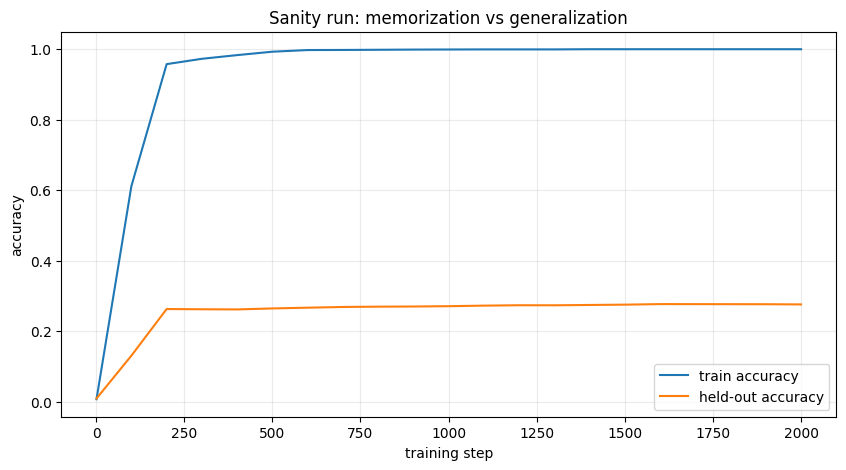

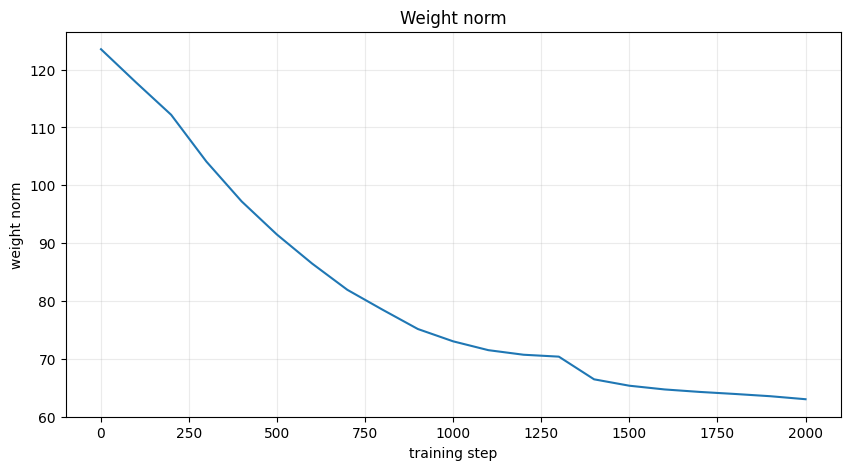

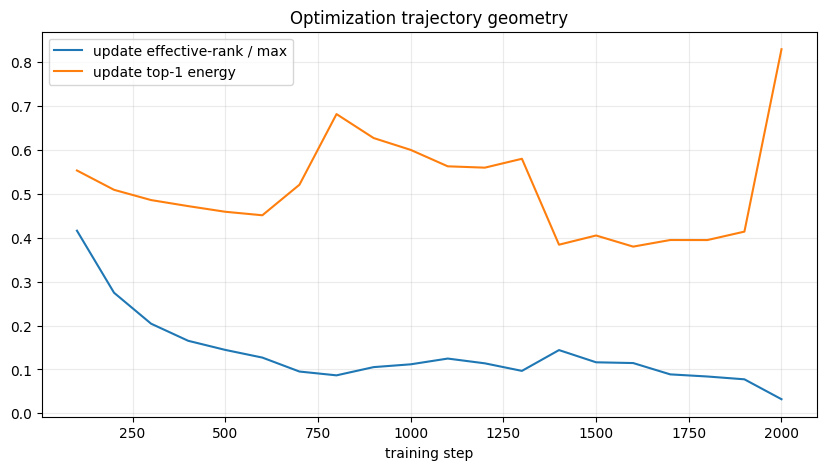

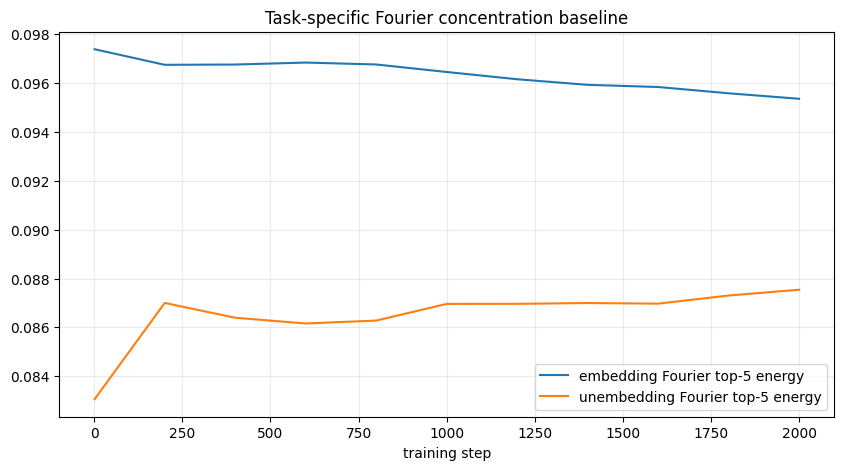

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df["meta_step"], df["feature_train_acc"], label="train accuracy")
plt.plot(df["meta_step"], df["label_test_acc"], label="held-out accuracy")
plt.xlabel("training step")
plt.ylabel("accuracy")
plt.title("Sanity run: memorization vs generalization")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["meta_step"], df["feature_weight_l2"], label="weight L2")
plt.xlabel("training step")
plt.ylabel("weight norm")
plt.title("Weight norm")
plt.grid(alpha=0.25)
plt.show()

diag = df.dropna(subset=["feature_update_effective_rank_norm"])
if len(diag):
    plt.figure(figsize=(10, 5))
    plt.plot(diag["meta_step"], diag["feature_update_effective_rank_norm"], label="update effective-rank / max")
    plt.plot(diag["meta_step"], diag["feature_update_top1_energy"], label="update top-1 energy")
    plt.xlabel("training step")
    plt.title("Optimization trajectory geometry")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

fourier = df.dropna(subset=["feature_fourier_embedding_top5_energy"])
if len(fourier):
    plt.figure(figsize=(10, 5))
    plt.plot(fourier["meta_step"], fourier["feature_fourier_embedding_top5_energy"], label="embedding Fourier top-5 energy")
    plt.plot(fourier["meta_step"], fourier["feature_fourier_unembed_top5_energy"], label="unembedding Fourier top-5 energy")
    plt.xlabel("training step")
    plt.title("Task-specific Fourier concentration baseline")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

In [6]:
last = df.iloc[-1]
train_acc = float(last["feature_train_acc"])
test_acc = float(last["label_test_acc"])

print(f"Final sanity train accuracy: {train_acc:.4f}")
print(f"Final sanity held-out accuracy: {test_acc:.4f}")

if train_acc >= 0.95 and test_acc < 0.80:
    print("PASS: the run is in/near the desired memorization-before-generalization regime.")
elif train_acc < 0.95:
    print("NOT READY: training has not memorized strongly yet; extend the sanity run before the full experiment.")
else:
    print("NOTE: held-out accuracy is already high. This seed/config may generalize too quickly for a clean delayed-grokking test.")

print("\nSaved outputs:")
print("/kaggle/working/tulya_runs/sanity_seed_0/metrics.csv")
print("/kaggle/working/tulya_runs/sanity_seed_0/step_metrics.csv")
print("/kaggle/working/tulya_runs/sanity_seed_0/spectra.jsonl")
print("/kaggle/working/tulya_runs/sanity_seed_0/summary.json")

Final sanity train accuracy: 1.0000
Final sanity held-out accuracy: 0.2762
PASS: the run is in/near the desired memorization-before-generalization regime.

Saved outputs:
/kaggle/working/tulya_runs/sanity_seed_0/metrics.csv
/kaggle/working/tulya_runs/sanity_seed_0/step_metrics.csv
/kaggle/working/tulya_runs/sanity_seed_0/spectra.jsonl
/kaggle/working/tulya_runs/sanity_seed_0/summary.json


## 2. Full 40,000-step run

Only enable this after the sanity run looks reasonable.

Change `RUN_FULL = False` to `True`. The default setup uses the reference-like grokking regime and saves checkpoints every 1,000 steps.

In [7]:
RUN_FULL = True

if RUN_FULL:
    full_cfg = ExperimentConfig(
        output_dir="/kaggle/working/tulya_runs/full_seed_0",
        seed=0,
    )
    full_summary = run_experiment(full_cfg)
    display(full_summary)
else:
    print("Full run is disabled. Set RUN_FULL = True when the sanity run looks good.")

step=     1 train_loss=4.8834 train_acc=0.007 test_acc=0.009 w_norm=123.53 grad=8.556e-01 upd_rank=nan
step=   100 train_loss=1.5991 train_acc=0.612 test_acc=0.131 w_norm=117.81 grad=3.088e-01 upd_rank=0.416
step=   200 train_loss=0.1101 train_acc=0.958 test_acc=0.263 w_norm=112.19 grad=1.264e-01 upd_rank=0.275
step=   300 train_loss=0.0622 train_acc=0.973 test_acc=0.262 w_norm=104.10 grad=8.900e-02 upd_rank=0.204
step=   400 train_loss=0.0371 train_acc=0.983 test_acc=0.262 w_norm=97.21 grad=5.996e-02 upd_rank=0.165
step=   500 train_loss=0.0169 train_acc=0.993 test_acc=0.265 w_norm=91.49 grad=6.625e-02 upd_rank=0.145
step=   600 train_loss=0.0070 train_acc=0.998 test_acc=0.267 w_norm=86.46 grad=2.269e-02 upd_rank=0.127
step=   700 train_loss=0.0051 train_acc=0.998 test_acc=0.269 w_norm=81.92 grad=2.474e-02 upd_rank=0.095
step=   800 train_loss=0.0036 train_acc=0.998 test_acc=0.270 w_norm=78.48 grad=1.515e-02 upd_rank=0.087
step=   900 train_loss=0.0028 train_acc=0.999 test_acc=0.270 w

{'output_dir': '/kaggle/working/tulya_runs/full_seed_0',
 'seed': 0,
 'modulus': 113,
 'operation': 'add',
 'train_examples': 3830,
 'test_examples': 8939,
 'num_parameters': 226048,
 'resolved_device': 'cuda',
 'completed_steps': 40000,
 'memorization_step': 500,
 'grokking_step': 14600,
 'grokking_observed': True,
 'lead_from_memorization_to_grokking': 14100,
 'final_train_acc': 1.0,
 'final_test_acc': 1.0,
 'wall_time_sec': 792.032428027}

## 3. Inspect the full run

Run this cell after the 40k experiment completes.

{'completed_steps': 40000,
 'final_test_acc': 1.0,
 'final_train_acc': 1.0,
 'grokking_observed': True,
 'grokking_step': 14600,
 'lead_from_memorization_to_grokking': 14100,
 'memorization_step': 500,
 'modulus': 113,
 'num_parameters': 226048,
 'operation': 'add',
 'output_dir': '/kaggle/working/tulya_runs/full_seed_0',
 'resolved_device': 'cuda',
 'seed': 0,
 'test_examples': 8939,
 'train_examples': 3830,
 'wall_time_sec': 792.032428027}

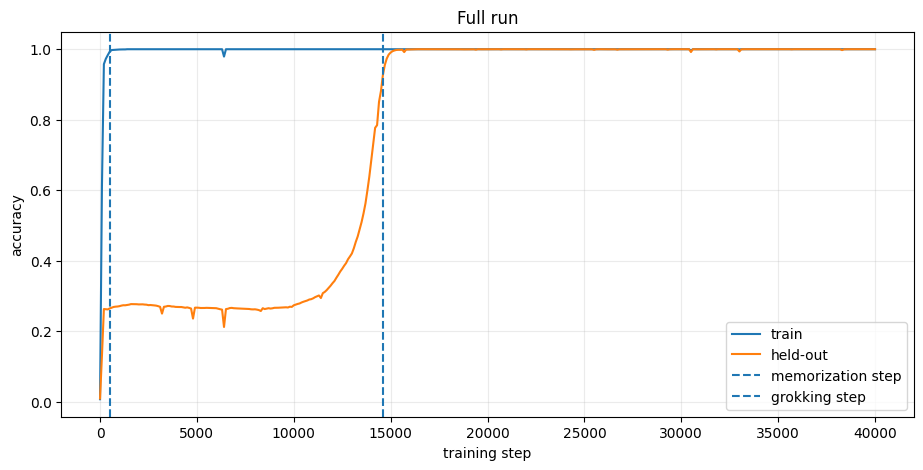

Online feature columns: 75
Retrospective label columns: 6


In [8]:
full_metrics = "/kaggle/working/tulya_runs/full_seed_0/metrics.csv"

if os.path.exists(full_metrics):
    full_df = pd.read_csv(full_metrics)
    with open("/kaggle/working/tulya_runs/full_seed_0/summary.json") as f:
        full_summary = json.load(f)

    display(full_summary)

    plt.figure(figsize=(11, 5))
    plt.plot(full_df["meta_step"], full_df["feature_train_acc"], label="train")
    plt.plot(full_df["meta_step"], full_df["label_test_acc"], label="held-out")
    if full_summary.get("memorization_step") is not None:
        plt.axvline(full_summary["memorization_step"], linestyle="--", label="memorization step")
    if full_summary.get("grokking_step") is not None:
        plt.axvline(full_summary["grokking_step"], linestyle="--", label="grokking step")
    plt.xlabel("training step")
    plt.ylabel("accuracy")
    plt.title("Full run")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    feature_cols = [c for c in full_df.columns if c.startswith("feature_")]
    label_cols = [c for c in full_df.columns if c.startswith("label_")]
    print("Online feature columns:", len(feature_cols))
    print("Retrospective label columns:", len(label_cols))
else:
    print("Full run outputs not found yet.")

## What to send back for analysis

After the sanity run, the most useful artifact is:

`/kaggle/working/tulya_runs/sanity_seed_0/metrics.csv`

After the full run, send:

- `metrics.csv`
- `summary.json`

The raw `spectra.jsonl` is useful later if we want deeper mechanistic analysis.